In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt

data = np.load("../data/shared_ring_dataset.npz", allow_pickle=True)

Y            = data["Y_rates"]       # (140, 1000, 100)
Y_theta      = data["Y_theta"]       # (140, 1000)
trial_types  = data["trial_types"]
theta_targets = data["theta_targets"]

# Identify trial indices by type
noise_idx  = np.where(trial_types == "noise_only")[0]
cue_idx    = np.where(trial_types == "single_cue")[0]
pert_idx   = np.where(trial_types == "perturbation")[0]

print(f"noise_only:   {len(noise_idx)} trials")
print(f"single_cue:   {len(cue_idx)} trials")
print(f"perturbation: {len(pert_idx)} trials")
print(f"Y_rates shape: {Y.shape}  (trials, bins, neurons)")

noise_only:   20 trials
single_cue:   100 trials
perturbation: 20 trials
Y_rates shape: (140, 1000, 100)  (trials, bins, neurons)


## The core question

In notebook `01_rate_ring_demo`, the decoded-angle **confidence** dropped sharply after the cue turned off.
Does that mean the bump **disappears**, making the post-cue data useless for training?

**Short answer:** No — confidence measures *certainty about the angle*, not *presence of a bump*.
- **Bump present but diffusing** → confidence gradually decreases because the bump is drifting to an unknown angle.
- **Bump gone / ring collapsed** → all neurons fire at equal low rates; confidence + mean activity both → 0.

The cells below test which case we actually have.

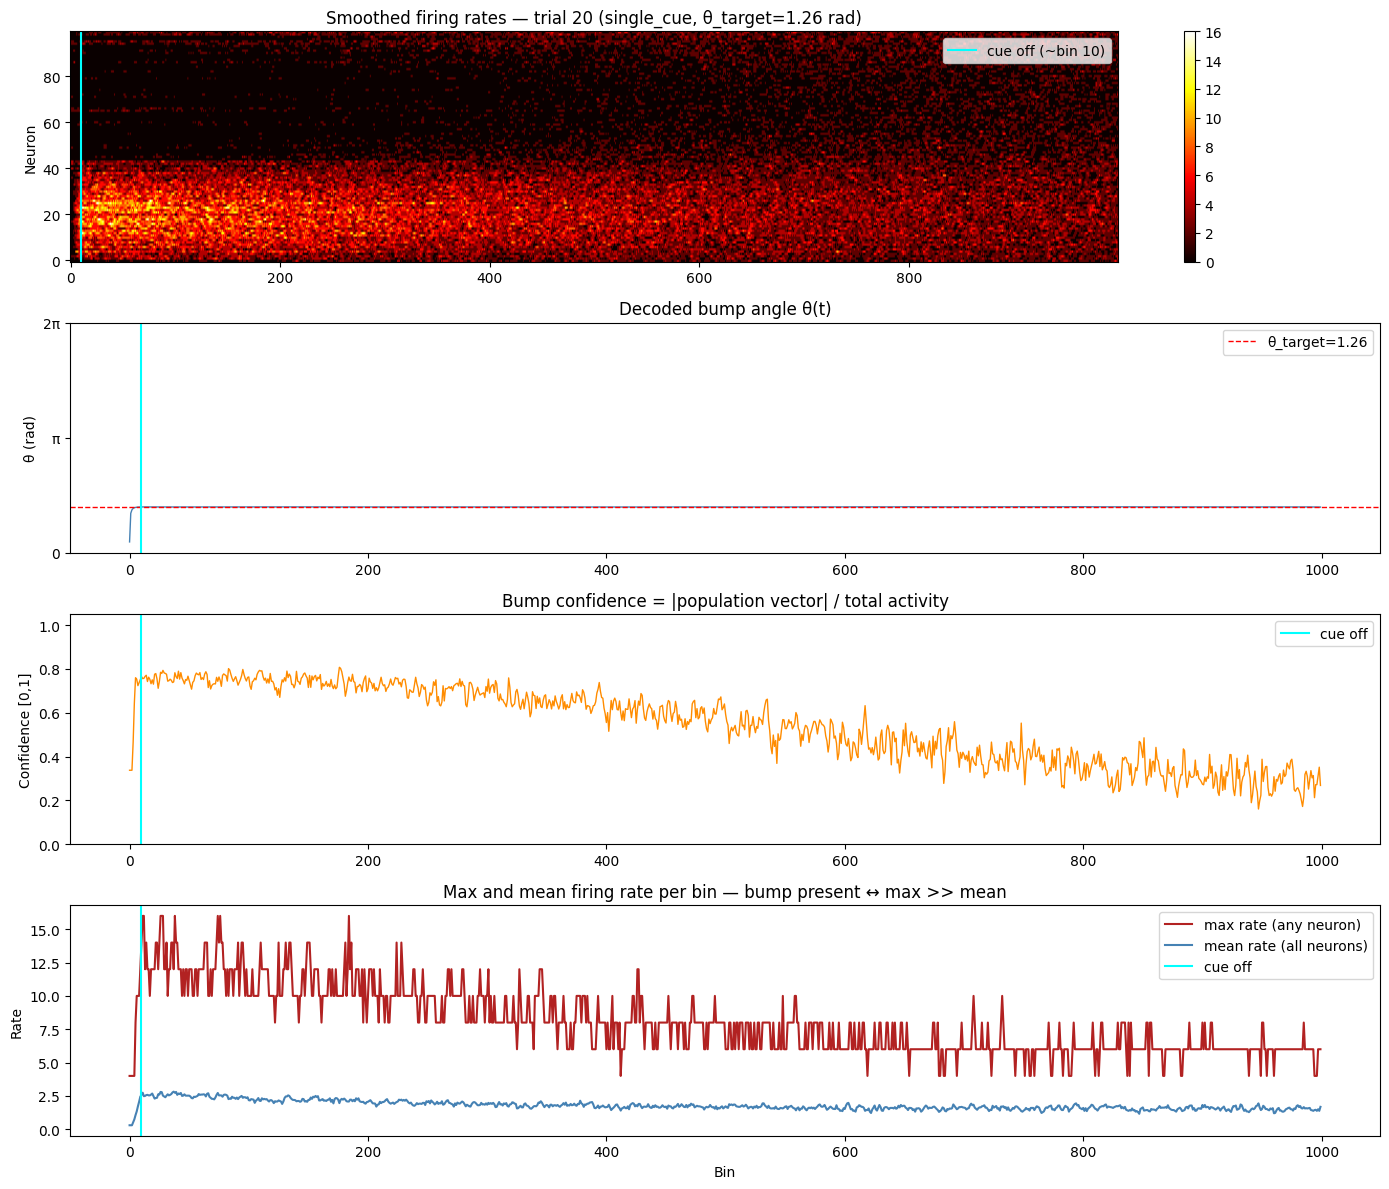

In [2]:
# Pick one single-cue trial and visualise the full 1000 bins
# (same style as notebook 01)

ti = cue_idx[0]   # first single-cue trial
rates  = Y[ti]        # (1000, 100)
theta  = Y_theta[ti]  # (1000,)
target = theta_targets[ti]

# Decoded confidence = mean resultant length of population vector
N = rates.shape[1]
angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
x_pop  = (rates * np.cos(angles)).sum(axis=1)
y_pop  = (rates * np.sin(angles)).sum(axis=1)
magnitude = np.sqrt(x_pop**2 + y_pop**2)       # raw bump amplitude
total_act  = rates.sum(axis=1)                  # total population activity
confidence = magnitude / (total_act + 1e-8)    # normalised: 1=perfect bump, 0=flat

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# 1. Rate heatmap
im = axes[0].imshow(rates.T, aspect="auto", origin="lower", cmap="hot")
axes[0].set_title(f"Smoothed firing rates — trial {ti} (single_cue, θ_target={target:.2f} rad)")
axes[0].set_ylabel("Neuron")
axes[0].axvline(10, color="cyan", linewidth=1.5, label="cue off (~bin 10)")  # cue_duration=500 steps / bin_factor=50
axes[0].legend()
plt.colorbar(im, ax=axes[0])

# 2. Decoded angle
axes[1].plot(theta, color="steelblue", linewidth=1)
axes[1].axhline(target, color="red", linestyle="--", linewidth=1, label=f"θ_target={target:.2f}")
axes[1].axvline(10, color="cyan", linewidth=1.5)
axes[1].set_title("Decoded bump angle θ(t)")
axes[1].set_ylabel("θ (rad)")
axes[1].set_yticks([0, np.pi, 2*np.pi])
axes[1].set_yticklabels(["0", "π", "2π"])
axes[1].legend()

# 3. Confidence
axes[2].plot(confidence, color="darkorange", linewidth=1)
axes[2].axvline(10, color="cyan", linewidth=1.5, label="cue off")
axes[2].set_title("Bump confidence = |population vector| / total activity")
axes[2].set_ylabel("Confidence [0,1]")
axes[2].set_ylim(0, 1.05)
axes[2].legend()

# 4. Max and mean rate per bin
axes[3].plot(rates.max(axis=1),  label="max rate (any neuron)", color="firebrick")
axes[3].plot(rates.mean(axis=1), label="mean rate (all neurons)", color="steelblue")
axes[3].axvline(10, color="cyan", linewidth=1.5, label="cue off")
axes[3].set_title("Max and mean firing rate per bin — bump present ↔ max >> mean")
axes[3].set_xlabel("Bin")
axes[3].set_ylabel("Rate")
axes[3].legend()

plt.tight_layout()
plt.show()

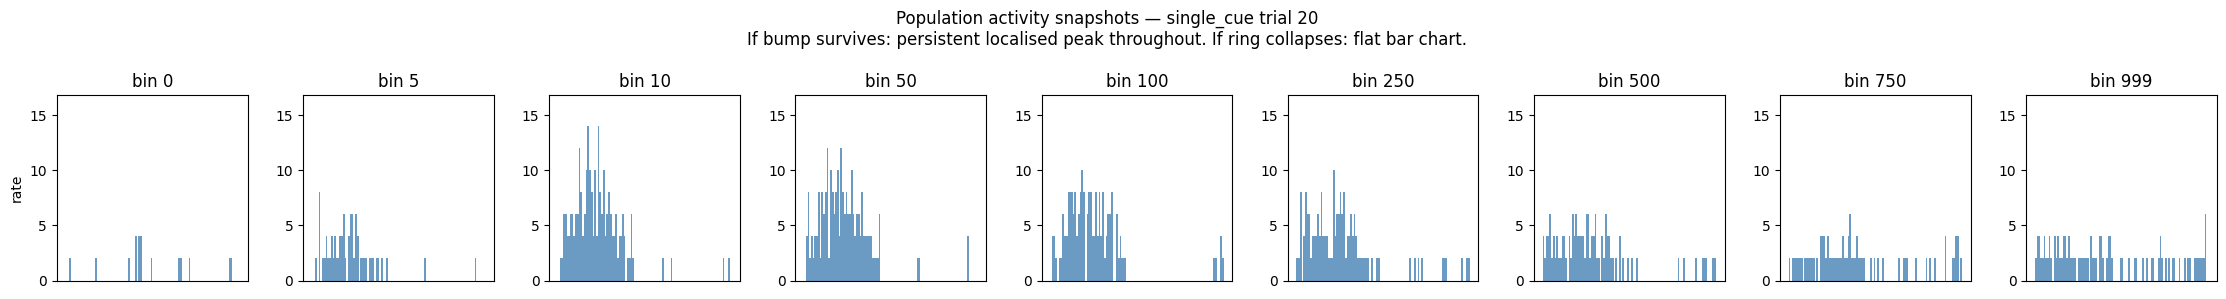

In [3]:
# Snapshots of population activity at key timepoints
# A bump looks like a localised peak. Noise looks flat.

snapshot_bins = [0, 5, 10, 50, 100, 250, 500, 750, 999]
fig, axes = plt.subplots(1, len(snapshot_bins), figsize=(2.5 * len(snapshot_bins), 3))

for ax, b in zip(axes, snapshot_bins):
    ax.bar(np.arange(N), rates[b], width=1.0, color="steelblue", alpha=0.8)
    ax.set_title(f"bin {b}")
    ax.set_ylim(0, rates.max() * 1.05)
    ax.set_xticks([])
    if b == snapshot_bins[0]:
        ax.set_ylabel("rate")

plt.suptitle(f"Population activity snapshots — single_cue trial {ti}\n"
             "If bump survives: persistent localised peak throughout. "
             "If ring collapses: flat bar chart.")
plt.tight_layout()
plt.show()

In [ ]:
# Compare bump survival across all single-cue trials
# Key metric: max_rate / mean_rate — should be >> 1 if a bump is present
# For a flat (no-bump) distribution this ratio = 1.
# For a sharp bump in 100 neurons: peak neuron fires ~10x mean, so ratio ≈ 10.

bump_ratio = Y[cue_idx].max(axis=2) / (Y[cue_idx].mean(axis=2) + 1e-8)  # (n_cue, 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Mean bump ratio over time, averaged across all cue trials
axes[0].plot(bump_ratio.mean(axis=0), color="steelblue", linewidth=1.5)
axes[0].fill_between(np.arange(1000),
                     bump_ratio.mean(axis=0) - bump_ratio.std(axis=0),
                     bump_ratio.mean(axis=0) + bump_ratio.std(axis=0),
                     alpha=0.2, color="steelblue")
axes[0].axhline(1.0, color="red", linestyle="--", label="ratio=1 (no bump)")
axes[0].set_xlabel("Bin")
axes[0].set_ylabel("max_rate / mean_rate")
axes[0].set_title("Bump ratio over time (all single-cue trials)\n"
                  ">> 1 = bump present, ≈ 1 = ring collapsed")
axes[0].legend()

# Same for noise-only trials as a baseline
bump_ratio_noise = Y[noise_idx].max(axis=2) / (Y[noise_idx].mean(axis=2) + 1e-8)
axes[1].plot(bump_ratio_noise.mean(axis=0), color="darkorange", linewidth=1.5, label="noise trials")
axes[1].plot(bump_ratio.mean(axis=0), color="steelblue", linewidth=1.5, label="single-cue trials")
axes[1].axhline(1.0, color="red", linestyle="--", label="ratio=1 (no bump)")
axes[1].set_xlabel("Bin")
axes[1].set_ylabel("max_rate / mean_rate")
axes[1].set_title("Bump ratio: cue trials vs noise trials\n"
                  "Cue >> noise → bump persists after cue")
axes[1].legend()

plt.tight_layout()
plt.show()

# Print summary
print("Mean bump ratio at selected bins (single-cue trials):")
for b in [0, 10, 50, 100, 250, 500, 750, 999]:
    r = bump_ratio[:, b].mean()
    print(f"  bin {b:4d}: {r:.2f}")

In [ ]:
# What does the DECODED ANGLE confidence actually measure?
# Low confidence ≠ no bump. It means we don't know WHERE the bump is.
#
# Analogy: GPS track with a car moving in fog.
#   High confidence = we know the car is at X (bump locked to target)
#   Low confidence  = car has drifted and could be anywhere on the road
#   But the CAR IS STILL ON THE ROAD (bump still exists)
#
# Below: compare confidence vs bump ratio for one trial.
# They should diverge after cue-off: confidence drops, bump ratio stays high.

ti = cue_idx[0]
rates     = Y[ti]
total_act = rates.sum(axis=1)
magnitude = np.sqrt(
    (rates * np.cos(angles)).sum(axis=1)**2 +
    (rates * np.sin(angles)).sum(axis=1)**2
)
confidence  = magnitude / (total_act + 1e-8)
bump_ratio1 = rates.max(axis=1) / (rates.mean(axis=1) + 1e-8)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.plot(confidence,  color="darkorange", linewidth=1.5, label="angle confidence (uncertain position)")
ax2.plot(bump_ratio1, color="steelblue",  linewidth=1.5, label="bump ratio (bump present?)")
ax1.axvline(10, color="cyan", linewidth=1.5, linestyle="--", label="cue off")

ax1.set_xlabel("Bin")
ax1.set_ylabel("Confidence [0,1]", color="darkorange")
ax2.set_ylabel("Max/mean rate ratio", color="steelblue")
ax1.set_title("Confidence vs bump ratio after cue-off\n"
              "Low confidence = unknown position (normal diffusion). "
              "Bump ratio >> 1 = bump still exists.")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()